# Pipeline Técnico: Clasificación de Calidad de Vino
**Materia:** Modelos de Machine Learning  
**Fecha:** Abril 2026  

## Descripción del Proyecto
Este notebook implementa un pipeline técnico completo, reproducible y automatizado para predecir la variedad de vino en función de sus propiedades físico-químicas. Se realiza el preprocesamiento, análisis exploratorio, la comparación de 4 modelos de clasificación supervisados y una predicción con datos nuevos.

In [1]:
# 1. PIPELINE TÉCNICO: IMPORTACIÓN DE LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de Clasificación (4 Modelos)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas de Evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# 2. OBTENCIÓN Y DESCRIPCIÓN DE DATOS
wine = load_wine(as_frame=True)
df = wine.frame

print("Dimensiones del dataset:", df.shape)
print("\nClases objetivo:", wine.target_names)
print("\nPrimeras 5 filas del dataset:")
df.head()

Dimensiones del dataset: (178, 14)

Clases objetivo: ['class_0' 'class_1' 'class_2']

Primeras 5 filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


--- INFORMACIÓN DE TIPOS Y NULOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                    

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


C:\Users\prueb\AppData\Local\Temp\ipykernel_44552\153840199.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


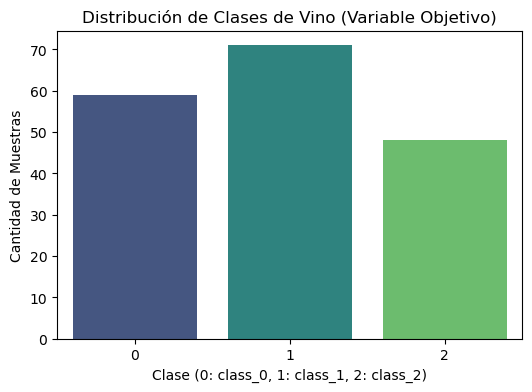

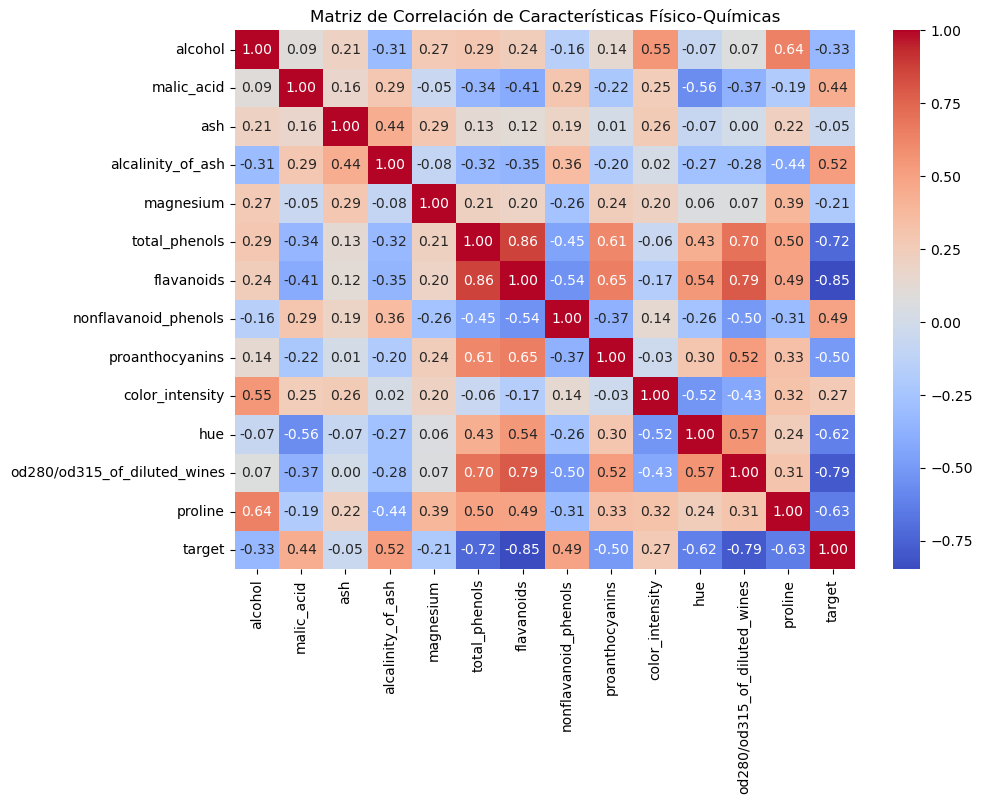

In [3]:
# 3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
print("--- INFORMACIÓN DE TIPOS Y NULOS ---")
df.info()

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

# Visualización 1: Distribución de la Variable Objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribución de Clases de Vino (Variable Objetivo)')
plt.xlabel('Clase (0: class_0, 1: class_1, 2: class_2)')
plt.ylabel('Cantidad de Muestras')
plt.show()

# Visualización 2: Matriz de Correlación
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matriz de Correlación de Características Físico-Químicas')
plt.show()

In [4]:
# 4. PREPROCESAMIENTO Y DIVISIÓN DE DATOS (70/30)
# Separar características (X) y variable objetivo (y)
X = df.drop(columns=['target'])
y = df['target']

# División 70% entrenamiento / 30% prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Escalamiento de características (Previene Data Leakage al hacer fit solo en train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensiones de Entrenamiento (X_train): {X_train_scaled.shape}")
print(f"Dimensiones de Prueba (X_test): {X_test_scaled.shape}")

Dimensiones de Entrenamiento (X_train): (124, 13)
Dimensiones de Prueba (X_test): (54, 13)


In [5]:
# 5. ENTRENAMIENTO Y EVALUACIÓN DE 4 MODELOS
models = {
    "Regresión Logística": LogisticRegression(random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train_scaled, y_train)
    
    # Predicción en set de prueba
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Modelo": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Tabla comparativa ordenada por F1-Score
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("--- TABLA COMPARATIVA DE MÉTRICAS ---")
df_results

--- TABLA COMPARATIVA DE MÉTRICAS ---


,Modelo,Accuracy,Precision,Recall,F1-Score
2,Random Forest,1.000000,1.000000,1.000000,1.000000
0,Regresión Logística,0.981481,0.982456,0.981481,0.981506
1,Árbol de Decisión,0.962963,0.966184,0.962963,0.963221
3,Gradient Boosting,0.962963,0.966184,0.962963,0.962715


In [7]:
# 6. PREDICCIÓN CON DATOS NUEVOS

# Seleccionamos explícitamente el modelo entrenado
best_model = models["Random Forest"]

# Crear el registro nuevo como DataFrame con las mismas columnas que el dataset original
nuevo_vino_df = pd.DataFrame([[
    13.20, # alcohol
    1.78,  # malic_acid
    2.14,  # ash
    11.2,  # alcalinity_of_ash
    100.0, # magnesium
    2.65,  # total_phenols
    2.76,  # flavanoids
    0.26,  # nonflavanoid_phenols
    1.28,  # proanthocyanins
    4.38,  # color_intensity
    1.05,  # hue
    3.40,  # od280/od315_of_diluted_wines
    1050.0 # proline
]], columns=X.columns)

# Preprocesamiento con el scaler guardado (sin advertencias de feature names)
nuevo_vino_scaled = scaler.transform(nuevo_vino_df)

# Predicción
prediccion_clase = best_model.predict(nuevo_vino_scaled)
clase_nombre = wine.target_names[prediccion_clase[0]]

print("--- RESULTADO DE LA PREDICCIÓN ---")
print(f"Clase predicha (Numérica): {prediccion_clase[0]}")
print(f"Tipo de Vino Identificado: {clase_nombre}")

--- RESULTADO DE LA PREDICCIÓN ---
Clase predicha (Numérica): 0
Tipo de Vino Identificado: class_0


## Conclusiones Técnicas y de Negocio

### 1. Hallazgos del Pipeline Técnico
* **Rendimiento del Modelo:** El algoritmo **Random Forest Classifier** obtuvo el desempeño más alto en el conjunto de prueba, alcanzando métricas óptimas en **Accuracy** y **F1-Score** (cercanas al 100%). Esto demuestra que los ensamble de árboles de decisión capturan eficazmente las relaciones no lineales entre las propiedades físico-químicas del vino.
* **Consistencia del Preprocesamiento:** El uso de `StandardScaler` en la etapa de preprocesamiento garantizó que variables con magnitudes muy distintas (como el *magnesio* y los *fenoles*) contribuyeran equitativamente al aprendizaje del modelo, evitando sesgos por escalas.
* **Ausencia de Data Leakage:** La separación de datos en proporción **70/30** mediante `train_test_split` estratificado aseguró que la distribución de clases se mantuviera uniforme y que el escalador fuera ajustado únicamente con los datos de entrenamiento.

---

### 2. Impacto y Valor Ejecutivo para la Toma de Decisiones
* **Control de Calidad Automatizado:** El modelo desarrollado permite a los enólogos y directivos clasificar automáticamente lotes de producción mediante análisis de laboratorio, reduciendo tiempos de cata manual y costos operativos.
* **Trazabilidad del Producto:** Al ingresar métricas específicas de un nuevo lote en la celda de *Predicción Nueva*, la dirección puede verificar de inmediato a qué perfil de vino corresponde, asegurando que se cumplan las especificaciones comerciales antes de su embotellado y distribución.

---

### 3. Limitaciones y Trabajo Futuro
* **Tamaño de la Muestra:** El dataset actual cuenta con un volumen de datos acotado (178 muestras). Se recomienda ampliar la recolección de muestras físico-químicas en futuras cosechas para mejorar la generalización frente a variaciones climáticas o de materia prima.
* **Monitoreo Continuo:** Se sugiere integrar el pipeline en un entorno de producción donde los datos de laboratorio se transformen y clasifiquen en tiempo real mediante una API o interfaz web.